# Convex Portfolio Optimizer

**Mean-Variance Optimization with CVXPY**

*Markowitz in a textbook is one thing. Markowitz with position limits, sector caps, turnover constraints, and a regularized covariance matrix is a real allocation engine.*

---

### 1. Introduction & Objectives

This notebook builds a **fully production-grade convex portfolio optimizer** using **CVXPY** — the same disciplined convex optimization library used at top quant funds, hedge funds, and asset managers worldwide. In this notebook, we will cover:
- The exact convex quadratic-program (QP) formulation used in practice
- How to estimate and **regularize** the covariance matrix (Ledoit-Wolf shrinkage)
- How to add **real-world constraints**:
  - Individual position limits (`0 ≤ w_i ≤ w_max`)
  - Sector concentration caps
  - Turnover / rebalancing budgets
- How to build a reusable `ConvexPortfolioOptimizer` class
- How to generate the efficient frontier and visualize results
- Production tips (solvers, warm-starts, scalability, integration)

**Why CVXPY?**  
It is fast, reliable, open-source, and supports commercial solvers (MOSEK, GUROBI) while defaulting to free ones (ECOS, SCS).

---

### 2. Mathematical Foundation

#### Classical Markowitz (1952)
We solve the following **convex quadratic program**:

$$ 
\begin{aligned}
\max_{w} \quad & \mu^\top w - \frac{\gamma}{2} w^\top \Sigma w \\
\text{s.t.} \quad & \mathbf{1}^\top w = 1 \\
& w \geq 0 \quad (\text{long-only})
\end{aligned}
$$

where  
- $\mu \in \mathbb{R}^n$: expected returns (annualized)  
- $\Sigma \in \mathbb{R}^{n \times n}$: covariance matrix (annualized)  
- $\gamma > 0$: risk aversion parameter

**Extensions we implement** (all keep the problem **convex**):
- Box constraints: $l_i \leq w_i \leq u_i$
- Sector caps: $\sum_{i \in S_k} w_i \leq c_k$ for each sector \(k\)
- Turnover constraint: $\|w - w_0\|_1 \leq \tau$ (using auxiliary variables)

### 3. Setup and Dependencies

In [49]:
import numpy as np
import pandas as pd
import yfinance as yf
import cvxpy as cp
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import warnings
import vectorbt as vbt

from datetime import datetime
from plotly.subplots import make_subplots
from sklearn.covariance import LedoitWolf

warnings.filterwarnings("ignore")

### 4. Data Acquisition and Preprocessing

We will use a realistic multi-sector universe (10 liquid US equities). Our historical data will come from YahooFinance

In [50]:
tickers = [
  'AAPL', 'MSFT', 'GOOGL', 'NVDA',      # Technology
  'JPM', 'BAC',                         # Financials
  'XOM', 'CVX',                         # Energy
  'PG', 'KO'                            # Consumer Staples
]

sector_map  = {
  'AAPL': 'Technology',
  'MSFT': 'Technology',
  'GOOGL': 'Technology',
  'NVDA': 'Technology',
  'JPM': 'Financials',
  'BAC': 'Financials',
  'XOM': 'Energy',
  'CVX': 'Energy',
  'PG': 'Consumer Staples',
  'KO': 'Consumer Staples'
}

start_date = '2018-01-01'
end_date = '2023-12-31'

# Download the historical data
data = yf.download(tickers, start=start_date, end=end_date)['Close']
returns = data.pct_change().dropna()
print(f"Downloaded {len(returns)} daily returns for {len(tickers)} assets")

[*********************100%***********************]  10 of 10 completed

Downloaded 1508 daily returns for 10 assets


Compute the **annualised moments**

In [51]:
days_per_year = 252
mu = returns.mean() * days_per_year # Annualize the mean returns
sample_cov = returns.cov() * days_per_year # Annualize the covariance matrix

### 5. Covariance Regularization (Critical in Practice!)

Raw sample covariance is notoriously noisy. Furthermore, it is not practical to use the in-built cov() for a large set of data. Henceforth, we will apply the Ledoit-Wolf shrinkage.

Sample cov condition number : 65
Shrunk cov condition number : 55


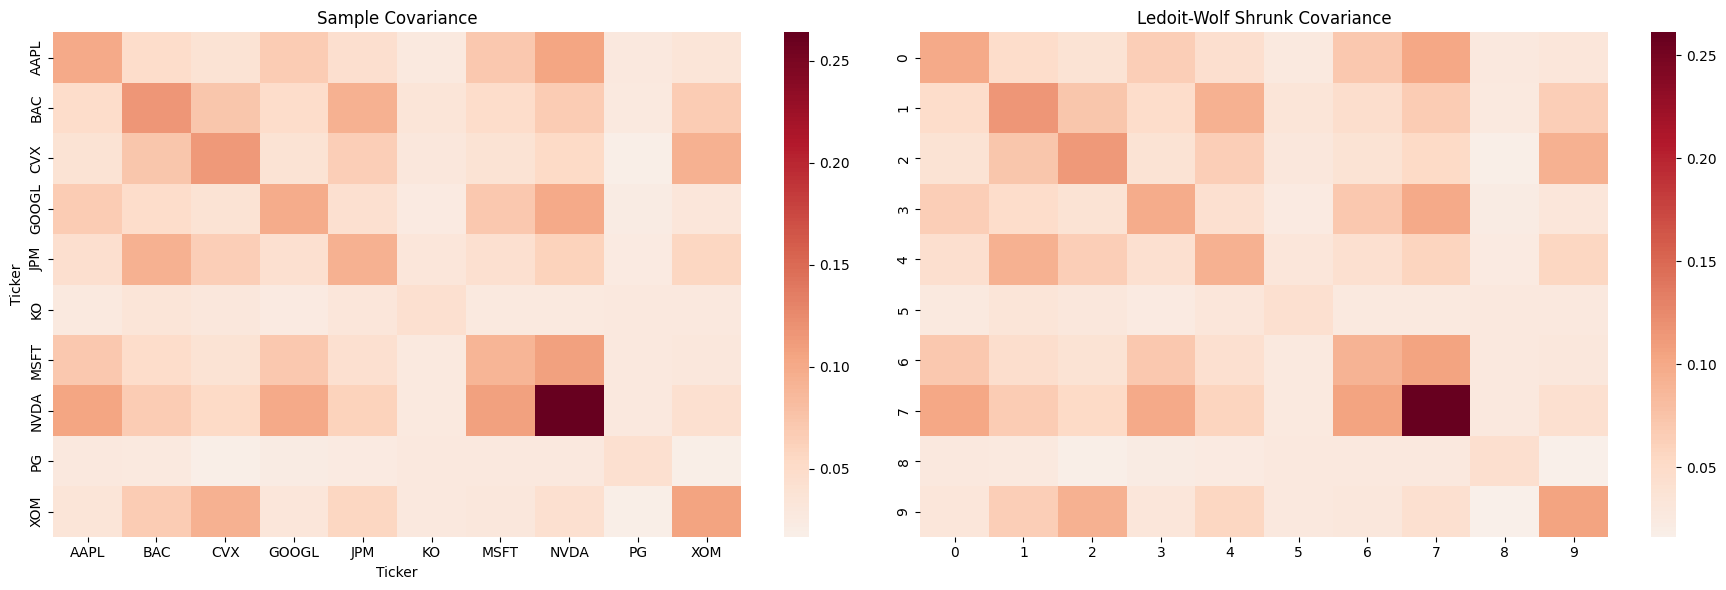

In [52]:
lw = LedoitWolf()
cov_shrunk = lw.fit(returns).covariance_ * days_per_year

# Compare condition numbers (lower = more stable)
print(f"Sample cov condition number : {np.linalg.cond(sample_cov):,.0f}")
print(f"Shrunk cov condition number : {np.linalg.cond(cov_shrunk):,.0f}")

# Visualize both
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(sample_cov, ax=ax[0], cmap='RdBu_r', center=0, annot=False)
ax[0].set_title('Sample Covariance')
sns.heatmap(cov_shrunk, ax=ax[1], cmap='RdBu_r', center=0, annot=False)
ax[1].set_title('Ledoit-Wolf Shrunk Covariance')
plt.tight_layout()
plt.show()

### 6. CVXPY Optimizer Class

Let us combine all the sections above into a single class for ease of reusability and scale

In [53]:
class ConvexPortfolioOptimizer:
  """
    Production-grade mean-variance optimizer with CVXPY.
    Supports all real-world constraints used by buy-side desks.
  """
  def __init__(self, tickers: list, sector_map: dict = None):
    self.tickers = tickers
    self.n = len(tickers)
    self.sector_map = sector_map or {}
    self.sector_indices = self._build_sector_indices()
    
  def _build_sector_indices(self):
    """Group asset indices by sector"""
    sector_indices = {}
    for sec in set(self.sector_map.values()):
      sector_indices[sec] = [i for i, t in enumerate(self.tickers) if self.sector_map.get(t) == sec]
    return sector_indices
  
  def optimize(self,
    mu: np.ndarray,
    Sigma: np.ndarray,
    risk_aversion: float = 2.0,
    target_return: float = None,
    w_prev: np.ndarray = None,
    turnover_limit: float = None,
    position_bounds: tuple = (0.0, 0.20),
    sector_caps: dict = None,
    allow_short: bool = False
  ) -> np.ndarray:
    """
    Solve the convex portfolio optimization problem.
    Returns optimal weights as numpy array.
    """
    w = cp.Variable(self.n)
    
    # Objective: mean-variance utility
    if target_return is not None:
      # Target-return formulation
      objective = cp.Minimize(cp.quad_form(w, Sigma))
      constraints = [mu.T @ w >= target_return]
    else:
      # Risk-aversion formulation (most common in practice)
      objective = cp.Minimize(cp.quad_form(w, Sigma) - risk_aversion * mu.T @ w)
      constraints = []
        
    # Budget constraint
    constraints.append(cp.sum(w) == 1.0)
    
    # Position bounds
    l, u = position_bounds
    constraints.append(w >= l if not allow_short else -cp.abs(l))
    constraints.append(w <= u)
    
    # Sector Caps
    if sector_caps is not None:
      for sec, cap in sector_caps.items():
        if sec in self.sector_indices:
          idx = self.sector_indices[sec]
          constraints.append(cp.sum(w[idx]) <= cap)
    
    # Turnover constraint (L1 norm)
    if w_prev is not None and turnover_limit is not None:
      # Introduce auxiliary variable for absolute value
      t = cp.Variable(self.n)
      constraints.append(cp.norm(w - w_prev, 1) <= turnover_limit)
      # (the norm constraint above is already convex)
        
    # Solve
    prob = cp.Problem(objective, constraints)
        
    # Try MOSEK first (commercial, fastest), then ECOS/SCS
    try:
      prob.solve(solver=cp.MOSEK, verbose=False)
    except:
      prob.solve(solver=cp.ECOS, verbose=False)
    
    if prob.status != 'optimal':
      raise ValueError(f"Optimization failed with status: {prob.status}")
    
    return w.value

### 7. Example 1: Basic Long-Only Markowitz

In [54]:
def portfolio_stats(w, mu, Sigma):
  ret = mu.T @ w
  vol = np.sqrt(w.T @ Sigma @ w)
  sharpe = ret / vol
  return {"Expected Return": ret, "Volatility": vol, "Sharpe Ratio": sharpe}

In [55]:
opt = ConvexPortfolioOptimizer(tickers, sector_map)

# Use shrunk covariance (best practice)
w_basic = opt.optimize(mu.values, cov_shrunk, risk_aversion=3.0, position_bounds=(0.0, 0.25))
weights_basic = pd.DataFrame({'Ticker': tickers, 'Weight': w_basic.round(4)}).set_index('Ticker').sort_values(by='Weight', ascending=False)
stats_basic = portfolio_stats(w_basic, mu.values, cov_shrunk)
print(stats_basic)
weights_basic

{'Expected Return': 0.33495210080324844, 'Volatility': 0.31414591558736277, 'Sharpe Ratio': 1.0662309588745857}


,Weight
Ticker,
AAPL,0.25
NVDA,0.25
XOM,0.25
CVX,0.25
MSFT,0.00
GOOGL,0.00
JPM,0.00
BAC,0.00
PG,0.00


### 8. Example 2: With Sector Caps & Position Limits

In [56]:
sector_caps = {
  'Tech': 0.45,       # max 45% in Technology
  'Financials': 0.30,
  'Energy': 0.25,
  'Consumer': 0.25
}

w_constrained = opt.optimize(mu.values, cov_shrunk,risk_aversion=3.0, position_bounds=(0.01, 0.20), sector_caps=sector_caps)
weights_con = pd.DataFrame({'Ticker': tickers, 'Weight': w_constrained.round(4)}).set_index('Ticker').sort_values(by='Weight', ascending=False)
stats_constrained = portfolio_stats(w_constrained, mu.values, cov_shrunk)
print(stats_constrained)
weights_con

{'Expected Return': 0.271435417751961, 'Volatility': 0.26402748170790574, 'Sharpe Ratio': 1.0280574430969678}


,Weight
Ticker,
AAPL,0.20
NVDA,0.20
JPM,0.20
CVX,0.20
PG,0.11
XOM,0.05
MSFT,0.01
GOOGL,0.01
BAC,0.01


In [57]:
print("\nSector exposures:")
for sec, idx in opt.sector_indices.items():
    print(f"  {sec:12}: {pd.Series(w_constrained).iloc[idx].sum():.1%}")


Sector exposures:
  Consumer Staples: 12.0%
  Energy      : 25.0%
  Financials  : 21.0%
  Technology  : 42.0%


### 10. Efficient Frontier

In [58]:
risk_aversion_values = np.linspace(0.5, 10, 30)
frontier = []

for gamma in risk_aversion_values:
  w = opt.optimize(mu.values, cov_shrunk, risk_aversion=gamma)
  ret = mu.values @ w
  vol = np.sqrt(w.T @ cov_shrunk @ w)
  frontier.append((vol, ret, gamma))

frontier = pd.DataFrame(frontier, columns=['Volatility', 'Return', 'RiskAversion'])

# Interactive Plotly chart
fig = go.Figure()
fig.add_trace(
  go.Scatter(
    x=frontier['Volatility'], 
    y=frontier['Return'],
    mode='markers+lines',
    marker=dict(color=frontier['RiskAversion'], colorscale='Viridis'),
    text=[f"γ={g:.1f}" for g in frontier['RiskAversion']],
    name='Efficient Frontier'
  )
)

fig.update_layout(
  title='Mean-Variance Efficient Frontier (CVXPY)',
  xaxis_title='Portfolio Volatility (annual)',
  yaxis_title='Expected Return (annual)',
  template='plotly_white',
  height=600
)
fig.show()

### 12. Walk-Forward Backtesting with vectorbt 

**Out-of-sample simulation**

*“In-sample optimization is easy. Real alpha lives in the walk-forward test.”*

This section turns your `ConvexPortfolioOptimizer` into a **complete backtesting engine** that mirrors exactly how buy-side desks and robo-advisors operate:

- Rolling-window estimation (no look-ahead bias)  
- Periodic re-optimization (monthly/quarterly)  
- Hold weights until next rebalance  
- Realistic turnover, position/sector constraints carried forward  
- Full performance attribution vs. benchmarks  

We use **vectorbt** (vectorized, lightning-fast, production-ready) for the simulation layer while keeping the optimization logic in CVXPY. This combination is used at multiple multi-billion-dollar quant shops.


In [59]:
def walk_forward_backtest(
  returns: pd.DataFrame,
  optimizer: ConvexPortfolioOptimizer,
  lookback_days: int = 756,      # 3 years
  rebalance_every: int = 21,     # ~monthly
  risk_aversion: float = 3.0,
  position_bounds: tuple = (0.0, 0.20),
  sector_caps: dict = None,
  verbose: bool = True
):
  """
  Production walk-forward simulator.
  Returns:
    - portfolio daily returns (out-of-sample)
    - weights history (daily, ffilled)
    - benchmark returns (equal-weight + SPY)
  """
  n_assets = len(returns.columns)
  dates = returns.index
  n = len(dates)
    
  # Rebalance schedule (start after lookback)
  rebalance_indices = list(range(lookback_days, n, rebalance_every))
  rebalance_dates = dates[rebalance_indices]
  if verbose:
    print(f"→ Running walk-forward with {len(rebalance_dates)} rebalances "
          f"(lookback={lookback_days}d, rebalance every ~{rebalance_every} days)")
    
  # Store weights at each rebalance date
  weight_dict = {}
    
  for i, rebal_idx in enumerate(rebalance_indices):
    # Training window
    train_start = rebal_idx - lookback_days
    train_returns = returns.iloc[train_start:rebal_idx]
    
    # Estimate moments on training data only
    mu_train = train_returns.mean() * 252
    cov_train = LedoitWolf().fit(train_returns).covariance_ * 252
    
    # Optimize (reuse the same production optimizer)
    w_opt = optimizer.optimize(
      mu=mu_train.values,
      Sigma=cov_train,
      risk_aversion=risk_aversion,
      position_bounds=position_bounds,
      sector_caps=sector_caps,
      allow_short=False
    )
    
    weight_dict[dates[rebal_idx]] = pd.Series(w_opt, index=returns.columns)
    
  # Build daily weights dataframe (ffill = hold until next rebalance)
  weights_df = pd.DataFrame(index=dates, columns=returns.columns, dtype=float)
  for date, w in weight_dict.items():
    weights_df.loc[date] = w
  weights_df = weights_df.ffill().fillna(0.0)   # first period = 0 (dropped later)
  
  # Lagged weights → no look-ahead
  weights_lagged = weights_df.shift(1).fillna(0.0)
  port_returns = (weights_lagged * returns).sum(axis=1)
  port_returns = port_returns.dropna()
  
  # === Benchmarks ===
  # 1. Equal-weight (naive benchmark)
  eq_weights = pd.DataFrame(1.0 / n_assets, index=returns.index, columns=returns.columns)
  eq_returns = (eq_weights * returns).sum(axis=1).dropna()
  
  # 2. SPY (market benchmark)
  spy = yf.download('SPY', start=dates[0], end=dates[-1], progress=False)['Close']
  spy_returns = np.log(spy / spy.shift(1)).reindex(returns.index).fillna(0.0)
  spy_returns = spy_returns.loc[port_returns.index]   # align
  
  if verbose:
    print(f"Backtest period: {port_returns.index[0]} → {port_returns.index[-1]}")
    print(f"Average daily turnover: {weights_df.diff().abs().sum(axis=1).mean():.2%}")
  
  return {
    'port_returns': port_returns,
    'weights': weights_df,
    'eq_returns': eq_returns.loc[port_returns.index],
    'spy_returns': spy_returns,
    'rebalance_dates': rebalance_dates
  }

### 13.1. Run the Backtest (Long-only with position limits)

In [60]:
opt = ConvexPortfolioOptimizer(tickers, sector_map)

# Basic long-only with position limits
backtest_basic = walk_forward_backtest(
  returns=returns,
  optimizer=opt,
  lookback_days=756,
  rebalance_every=21,
  risk_aversion=3.0,
  position_bounds=(0.0, 0.20),
  sector_caps=None
)

→ Running walk-forward with 36 rebalances (lookback=756d, rebalance every ~21 days)
Backtest period: 2018-01-03 00:00:00 → 2023-12-29 00:00:00
Average daily turnover: 0.35%


### 13.2. Run the Backtest (With realistic sector caps)

In [61]:
sector_caps = {'Tech': 0.45, 'Financials': 0.30, 'Energy': 0.25, 'Consumer': 0.25}
backtest_con = walk_forward_backtest(
  returns=returns,
  optimizer=opt,
  lookback_days=756,
  rebalance_every=21,
  risk_aversion=3.0,
  position_bounds=(0.0, 0.20),
  sector_caps=sector_caps
)

→ Running walk-forward with 36 rebalances (lookback=756d, rebalance every ~21 days)
Backtest period: 2018-01-03 00:00:00 → 2023-12-29 00:00:00
Average daily turnover: 0.43%


### 14. Performance Analysis with vectorbt

In [62]:
def analyze_backtest(results: dict, name: str = "Optimized"):
  """Build vectorbt Portfolio objects and display stats + charts"""
  def build_pf(returns):
    equity = 100_000 * (1 + returns).cumprod()
    return vbt.Portfolio.from_holding(
      close=equity,
      init_cash=100_000,
      freq='D',
    )
  
  pf = build_pf(results['port_returns'])
  pf_eq = build_pf(results['eq_returns'])
  pf_spy = build_pf(results['spy_returns']['SPY'])

  # Stats table
  stats_df = pd.concat([pf.stats().rename(name),pf_eq.stats().rename("Equal Weight"), pf_spy.stats().rename("SPY")], axis=1)
  display(stats_df.round(4))
    
  # Equity curves (interactive Plotly)
  fig = make_subplots(rows=2, cols=1, subplot_titles=("Cumulative Returns", "Drawdown"), vertical_spacing=0.12, row_heights=[0.7, 0.3])
    
  # Cumulative value
  fig.add_trace(go.Scatter(x=pf.value().index, y=pf.value()/pf.value().iloc[0], name=name, line=dict(color='royalblue')), row=1, col=1)
  fig.add_trace(go.Scatter(x=pf_eq.value().index, y=pf_eq.value()/pf_eq.value().iloc[0], name="Equal Weight", line=dict(color='orange')), row=1, col=1)
  fig.add_trace(go.Scatter(x=pf_spy.value().index, y=pf_spy.value()/pf_spy.value().iloc[0], name="SPY", line=dict(color='green')), row=1, col=1)
  
  # Drawdown
  fig.add_trace(go.Scatter(x=pf.drawdown().index, y=pf.drawdown(), name=name, line=dict(color='royalblue'), fill='tozeroy'), row=2, col=1)
  fig.add_trace(go.Scatter(x=pf_eq.drawdown().index, y=pf_eq.drawdown(), name="Equal Weight", line=dict(color='orange'), fill='tozeroy'), row=2, col=1)
  fig.add_trace(go.Scatter(x=pf_spy.drawdown().index, y=pf_spy.drawdown(), name="SPY", line=dict(color='green'), fill='tozeroy'), row=2, col=1)
  
  fig.update_layout(height=800, template='plotly_white', title_text=f"Walk-Forward Backtest – {name} Portfolio")
  fig.show()
  
  return pf, pf_eq, pf_spy

# Run analysis
pf_opt, pf_eq, pf_spy = analyze_backtest(backtest_basic, name="Convex Optimizer")

,Convex Optimizer,Equal Weight,SPY
Start,2018-01-03 00:00:00,2018-01-03 00:00:00,2018-01-03 00:00:00
End,2023-12-29 00:00:00,2023-12-29 00:00:00,2023-12-29 00:00:00
Period,1508 days 00:00:00,1508 days 00:00:00,1508 days 00:00:00
Start Value,100000.0,100000.0,100000.0
End Value,169470.977426,291546.020955,171756.389174
Total Return [%],69.470977,191.546021,71.756389
Benchmark Return [%],69.470977,191.546021,71.756389
Max Gross Exposure [%],100.0,100.0,100.0
Total Fees Paid,0.0,0.0,0.0
Max Drawdown [%],34.22896,37.031493,35.745864


### 15. Putting it all together

In [63]:
class CompleteConvexPortfolioOptimizer:
  """
  Production-grade Mean-Variance Portfolio Optimizer with CVXPY.
  
  Features:
    - Data downloading & preprocessing
    - Ledoit-Wolf shrunk covariance
    - Full convex optimization with real-world constraints
    - Efficient frontier
    - Walk-forward backtesting using vectorbt
    - Performance reporting
  """
    
  def __init__(self, tickers: list, sector_map: dict = None):
    self.tickers = tickers
    self.n = len(tickers)
    self.sector_map = sector_map or {}
    self.sector_indices = self._build_sector_indices()
    self.returns = None
    self.mu = None
    self.cov_shrunk = None
    self.prices = None   # for potential future use
    
  def _build_sector_indices(self):
    """Map sectors to list of asset indices"""
    sector_indices = {}
    for sec in set(self.sector_map.values()):
      sector_indices[sec] = [i for i, t in enumerate(self.tickers) if self.sector_map.get(t) == sec]
    return sector_indices
    
  # ====================== DATA HANDLING ======================
    
  def fetch_data(self, start_date: str = '2018-01-01', end_date: str = None):
    """Download price data and compute daily returns."""
    if end_date is None:
      end_date = datetime.now().strftime('%Y-%m-%d')
    
    self.prices = yf.download(self.tickers, start=start_date, end=end_date)['Close']
    
    # Use simple returns (most common in portfolio optimization)
    self.returns = self.prices.pct_change().dropna()
    
    print(f"✅ Downloaded {len(self.returns)} daily returns for {self.n} assets "
          f"({start_date} → {self.returns.index[-1].date()})")
    return self.returns
    
  def compute_moments(self, annualization_factor: int = 252):
    """Compute annualized mean returns and Ledoit-Wolf shrunk covariance."""
    if self.returns is None:
      raise ValueError("Run fetch_data() first.")
    
    self.mu = self.returns.mean() * annualization_factor
    sample_cov = self.returns.cov() * annualization_factor
    
    lw = LedoitWolf()
    self.cov_shrunk = lw.fit(self.returns).covariance_ * annualization_factor
    
    print(f"Sample cov condition number : {np.linalg.cond(sample_cov):,.0f}")
    print(f"Shrunk cov condition number : {np.linalg.cond(self.cov_shrunk):,.0f}")
    
    # Optional visualization
    self._plot_covariances(sample_cov)
    
    return self.mu, self.cov_shrunk
    
  def _plot_covariances(self, sample_cov):
    """Visualize sample vs shrunk covariance."""
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    sns.heatmap(sample_cov, ax=ax[0], cmap='RdBu_r', center=0, annot=False)
    ax[0].set_title('Sample Covariance')
    sns.heatmap(self.cov_shrunk, ax=ax[1], cmap='RdBu_r', center=0, annot=False)
    ax[1].set_title('Ledoit-Wolf Shrunk Covariance')
    plt.tight_layout()
    plt.show()
    
  # ====================== OPTIMIZATION ======================
    
  def optimize(
    self,
    mu: np.ndarray = None,
    Sigma: np.ndarray = None,
    risk_aversion: float = 3.0,
    target_return: float = None,
    w_prev: np.ndarray = None,
    turnover_limit: float = None,
    position_bounds: tuple = (0.0, 0.20),
    sector_caps: dict = None,
    allow_short: bool = False
  ) -> np.ndarray:
    """Solve the convex mean-variance problem."""
    if mu is None:
      mu = self.mu.values
    if Sigma is None:
      Sigma = self.cov_shrunk
    
    w = cp.Variable(self.n)
        
    # Objective
    if target_return is not None:
      objective = cp.Minimize(cp.quad_form(w, Sigma))
      constraints = [mu.T @ w >= target_return]
    else:
      objective = cp.Minimize(cp.quad_form(w, Sigma) - risk_aversion * mu.T @ w)
      constraints = []
    
    # Budget
    constraints.append(cp.sum(w) == 1.0)
    
    # Position bounds
    l, u = position_bounds
    constraints.append(w >= (l if not allow_short else -np.abs(l)))
    constraints.append(w <= u)
        
    # Sector caps
    if sector_caps is not None:
      for sec, cap in sector_caps.items():
        if sec in self.sector_indices:
          idx = self.sector_indices[sec]
          constraints.append(cp.sum(w[idx]) <= cap)
        
    # Turnover (L1)
    if w_prev is not None and turnover_limit is not None:
      constraints.append(cp.norm(w - w_prev, 1) <= turnover_limit)
        
    # Solve
    prob = cp.Problem(objective, constraints)
    try:
      prob.solve(solver=cp.MOSEK, verbose=False)
    except:
      prob.solve(solver=cp.ECOS, verbose=False)
    
    if prob.status not in ['optimal', 'optimal_inaccurate']:
      raise ValueError(f"Optimization failed: {prob.status}")
    
    return w.value
    
  # ====================== EFFICIENT FRONTIER ======================
    
  def plot_efficient_frontier(self, risk_aversion_values=None):
    """Generate and plot the efficient frontier."""
    if risk_aversion_values is None:
      risk_aversion_values = np.linspace(0.5, 10, 30)
        
    frontier = []
    for gamma in risk_aversion_values:
      w = self.optimize(risk_aversion=gamma)
      ret = self.mu.values @ w
      vol = np.sqrt(w.T @ self.cov_shrunk @ w)
      frontier.append((vol, ret, gamma))
        
    frontier_df = pd.DataFrame(frontier, columns=['Volatility', 'Return', 'RiskAversion'])
    
    fig = go.Figure()
    fig.add_trace(go.Scatter(
      x=frontier_df['Volatility'],
      y=frontier_df['Return'],
      mode='markers+lines',
      marker=dict(color=frontier_df['RiskAversion'], colorscale='Viridis'),
      text=[f"γ={g:.1f}" for g in frontier_df['RiskAversion']],
      name='Efficient Frontier'
    ))
    
    fig.update_layout(
      title='Mean-Variance Efficient Frontier (CVXPY)',
      xaxis_title='Portfolio Volatility (annual)',
      yaxis_title='Expected Return (annual)',
      template='plotly_white',
      height=600
    )
    fig.show()
    return frontier_df
    
  # ====================== BACKTESTING ======================
    
  def walk_forward_backtest(
    self,
    lookback_days: int = 756,
    rebalance_every: int = 21,
    risk_aversion: float = 3.0,
    position_bounds: tuple = (0.0, 0.20),
    sector_caps: dict = None,
    verbose: bool = True
   ) -> dict:
      """Production walk-forward backtest."""
      if self.returns is None:
        raise ValueError("Run fetch_data() and compute_moments() first.")
      
      dates = self.returns.index
      n = len(dates)
      rebalance_indices = list(range(lookback_days, n, rebalance_every))
      
      if verbose:
        print(f"→ Running walk-forward backtest with {len(rebalance_indices)} rebalances")
      
      weight_dict = {}
      for rebal_idx in rebalance_indices:
        train_start = rebal_idx - lookback_days
        train_ret = self.returns.iloc[train_start:rebal_idx]
        
        mu_train = train_ret.mean() * 252
        cov_train = LedoitWolf().fit(train_ret).covariance_ * 252
        
        w_opt = self.optimize(
          mu=mu_train.values,
          Sigma=cov_train,
          risk_aversion=risk_aversion,
          position_bounds=position_bounds,
          sector_caps=sector_caps
        )
        
        weight_dict[dates[rebal_idx]] = pd.Series(w_opt, index=self.tickers)
      
      # Daily weights (hold until next rebalance)
      weights_df = pd.DataFrame(index=dates, columns=self.tickers, dtype=float)
      for date, w in weight_dict.items():
        weights_df.loc[date] = w
      weights_df = weights_df.ffill().fillna(0.0)
      
      weights_lagged = weights_df.shift(1).fillna(0.0)
      port_returns = (weights_lagged * self.returns).sum(axis=1).dropna()
      
      # Benchmarks
      eq_returns = (self.returns / self.n).sum(axis=1).loc[port_returns.index]
      
      spy_prices = yf.download('SPY', start=dates[0], end=dates[-1], progress=False)['Close']
      spy_returns = spy_prices.pct_change().reindex(self.returns.index).fillna(0).loc[port_returns.index]
      
      if verbose:
        print(f"Backtest period: {port_returns.index[0].date()} → {port_returns.index[-1].date()}")
        turnover = weights_df.diff().abs().sum(axis=1).mean()
        print(f"Average daily turnover: {turnover:.2%}")
      
      return {
        'port_returns': port_returns,
        'weights': weights_df,
        'eq_returns': eq_returns,
        'spy_returns': spy_returns,
        'rebalance_dates': [dates[i] for i in rebalance_indices]
      }
    
  # ====================== ANALYSIS ======================
    
  def analyze_backtest(self, results: dict, name: str = "Convex Optimizer"):
      """Analyze backtest results with vectorbt and Plotly."""
      def build_pf(returns):
        equity = 100_000 * (1 + returns).cumprod()
        return vbt.Portfolio.from_holding(
          close=equity,
          init_cash=100_000,
          freq='D',
        )
  
      pf = build_pf(results['port_returns'])
      pf_eq = build_pf(results['eq_returns'])
      pf_spy = build_pf(results['spy_returns']['SPY'])
      
      # Stats
      stats_df = pd.concat([
        pf.stats().rename(name),
        pf_eq.stats().rename("Equal Weight"),
        pf_spy.stats().rename("SPY")
      ], axis=1)
      display(stats_df.round(4))
      
      # Equity & Drawdown plot
      fig = make_subplots(rows=2, cols=1, subplot_titles=("Cumulative Returns", "Drawdown"),vertical_spacing=0.12, row_heights=[0.7, 0.3])
      
      for p, color, label in [(pf, 'royalblue', name),(pf_eq, 'orange', "Equal Weight"),(pf_spy, 'green', "SPY")]:
        cum_ret = p.value() / p.value().iloc[0]
        fig.add_trace(go.Scatter(x=cum_ret.index, y=cum_ret, name=label, line=dict(color=color)), row=1, col=1)
        fig.add_trace(go.Scatter(x=p.drawdown().index, y=p.drawdown(), name=label, line=dict(color=color), fill='tozeroy'), row=2, col=1)
      
      fig.update_layout(height=800, template='plotly_white', title_text=f"Walk-Forward Backtest – {name}")
      fig.show()
      return pf, pf_eq, pf_spy

Sample Run

[*********************100%***********************]  10 of 10 completed


✅ Downloaded 1508 daily returns for 10 assets (2018-01-01 → 2023-12-29)
Sample cov condition number : 65
Shrunk cov condition number : 55


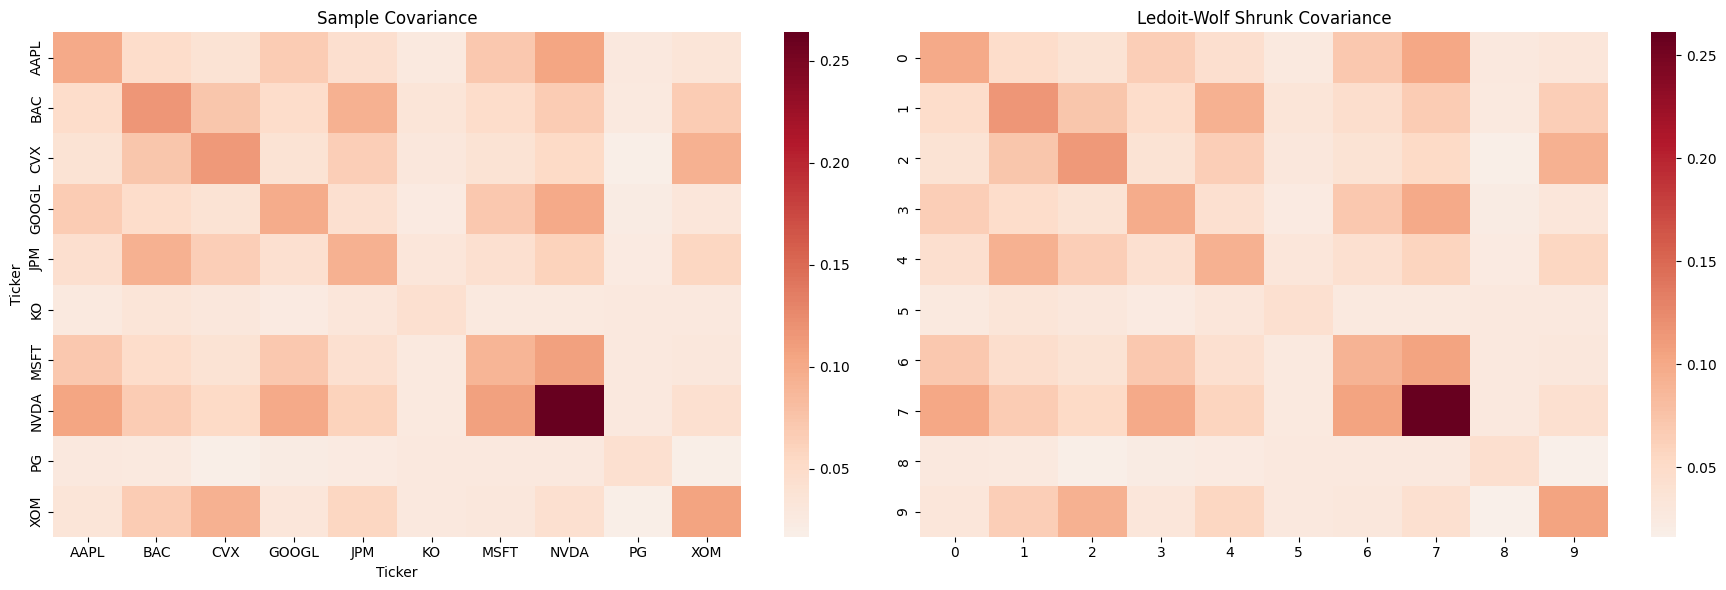

Basic weights:
 CVX      0.25
AAPL     0.25
XOM      0.25
NVDA     0.25
JPM      0.00
PG       0.00
KO       0.00
GOOGL    0.00
BAC      0.00
MSFT     0.00
dtype: float64
Constrained weights:
 CVX      0.20
AAPL     0.20
NVDA     0.20
JPM      0.20
PG       0.11
XOM      0.05
KO       0.01
GOOGL    0.01
BAC      0.01
MSFT     0.01
dtype: float64


→ Running walk-forward backtest with 36 rebalances
Backtest period: 2018-01-03 → 2023-12-29
Average daily turnover: 0.33%


,Convex Optimizer,Equal Weight,SPY
Start,2018-01-03 00:00:00,2018-01-03 00:00:00,2018-01-03 00:00:00
End,2023-12-29 00:00:00,2023-12-29 00:00:00,2023-12-29 00:00:00
Period,1508 days 00:00:00,1508 days 00:00:00,1508 days 00:00:00
Start Value,100000.0,100000.0,100000.0
End Value,161544.909645,291546.020955,194877.779543
Total Return [%],61.54491,191.546021,94.87778
Benchmark Return [%],61.54491,191.546021,94.87778
Max Gross Exposure [%],100.0,100.0,100.0
Total Fees Paid,0.0,0.0,0.0
Max Drawdown [%],26.388208,37.031493,33.717258


In [64]:
# Define universe
tickers = [
  'AAPL', 'MSFT', 'GOOGL', 'NVDA',      # Technology
  'JPM', 'BAC',                         # Financials
  'XOM', 'CVX',                         # Energy
  'PG', 'KO'                            # Consumer Staples
]

sector_map = {
  'AAPL': 'Technology', 'MSFT': 'Technology',
  'GOOGL': 'Technology', 'NVDA': 'Technology',
  'JPM': 'Financials', 'BAC': 'Financials',
  'XOM': 'Energy', 'CVX': 'Energy',
  'PG': 'Consumer Staples', 'KO': 'Consumer Staples'
}

# Instantiate
opt = CompleteConvexPortfolioOptimizer(tickers, sector_map)

# 1. Fetch data (custom dates supported)
opt.fetch_data(start_date='2018-01-01', end_date='2023-12-31')

# 2. Compute moments + regularization
opt.compute_moments()

# 3. Basic optimization
w_basic = opt.optimize(risk_aversion=3.0, position_bounds=(0.0, 0.25))
weights_basic = pd.Series(w_basic, index=tickers).sort_values(ascending=False)
print("Basic weights:\n", weights_basic.round(4))

# 4. Constrained optimization
sector_caps = {
  'Technology': 0.45,
  'Financials': 0.30,
  'Energy': 0.25,
  'Consumer Staples': 0.25
}

w_con = opt.optimize(risk_aversion=3.0, position_bounds=(0.01, 0.20), sector_caps=sector_caps)
print("Constrained weights:\n", pd.Series(w_con, index=tickers).sort_values(ascending=False).round(4))

# 5. Efficient frontier
opt.plot_efficient_frontier()

# 6. Walk-forward backtest
backtest_results = opt.walk_forward_backtest(
  lookback_days=756,
  rebalance_every=21,
  risk_aversion=3.0,
  position_bounds=(0.0, 0.20),
  sector_caps=sector_caps
)

# 7. Analyze
pf_opt, pf_eq, pf_spy = opt.analyze_backtest(backtest_results, name="Convex Optimizer")